In [32]:
import pandas as pd


In [33]:
calendar_df = pd.read_csv('calendar.csv')
listing_df = pd.read_csv('listings.csv')
neighbour_df = pd.read_csv('neighbourhoods.csv')
review_df = pd.read_csv('reviews.csv')

In [34]:
listing_info_df = pd.read_csv('listings_info.csv')

In [35]:
datasets = [calendar_df, listing_df, neighbour_df, review_df]
for i in datasets:
    print('Dataset name:')
    print('_______________________________________________________________________________________')
    print(i.info())
    print(i.describe())
    print(((i.isnull().sum())/len(i))*100,'%')
    print('_______________________________________________________________________________________')

Dataset name:
_______________________________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161995 entries, 0 to 3161994
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           float64
 4   adjusted_price  float64
 5   minimum_nights  int64  
 6   maximum_nights  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 168.9+ MB
None
         listing_id  price  adjusted_price  minimum_nights  maximum_nights
count  3.161995e+06    0.0             0.0    3.161995e+06    3.161995e+06
mean   7.477230e+17    NaN             NaN    1.502865e+01    3.062970e+05
std    5.617101e+17    NaN             NaN    2.672339e+01    2.561678e+07
min    2.384000e+03    NaN             NaN    1.000000e+00    1.000000e+00
25%    4.873326e+07    NaN             NaN    2.000000e+00    3.650000e+02
50%   

In [36]:
listing_df['host_name'] = listing_df.groupby('host_id')['host_name'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

/tmp/ipykernel_2818/2674008553.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  listing_df['host_name'] = listing_df.groupby('host_id')['host_name'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
/tmp/ipykernel_2818/2674008553.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  listing_df['host_name'] = listing_df.groupby('host_id')['host_name'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


In [37]:
listing_df['host_name'].isnull().sum()/len(listing_df)

np.float64(0.07168417407364654)

In [38]:
listing_df['reviews_per_month'].isnull().sum()/len(listing_df)

np.float64(0.19450536765554657)

In [39]:
listing_df['license'] = listing_df['license'].fillna('Not Provided')

In [40]:
zero_review_mask = listing_df['number_of_reviews'] == 0
missing_rpm_mask = listing_df['reviews_per_month'].isna()

if zero_review_mask.sum() == missing_rpm_mask.sum():
    print("Have 0 total reviews")
else:
    print("Not all missing values have total reviews")

Have 0 total reviews


In [41]:
listing_df['reviews_per_month'] = listing_df['reviews_per_month'].fillna(0.0)

In [42]:
listing_df['last_review'] = listing_df['last_review'].fillna('Not Provided')

In [43]:
listing_df.drop(columns=['neighbourhood_group'], axis=1, inplace=True, errors='ignore')

In [44]:
listing_df['host_name'] = listing_df['host_name'].fillna('Unknown Host')

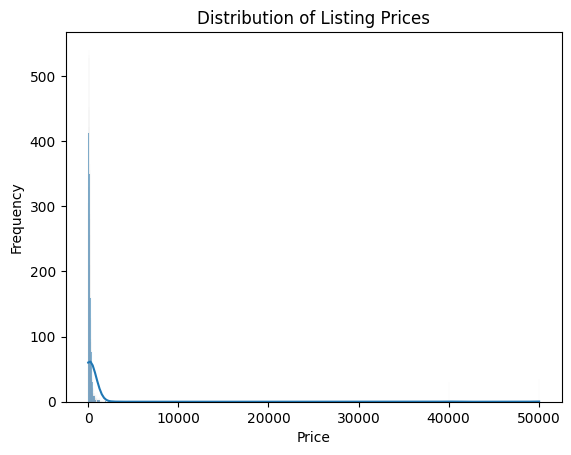

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(listing_df['price'],kde=True)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Listing Prices')
plt.show()

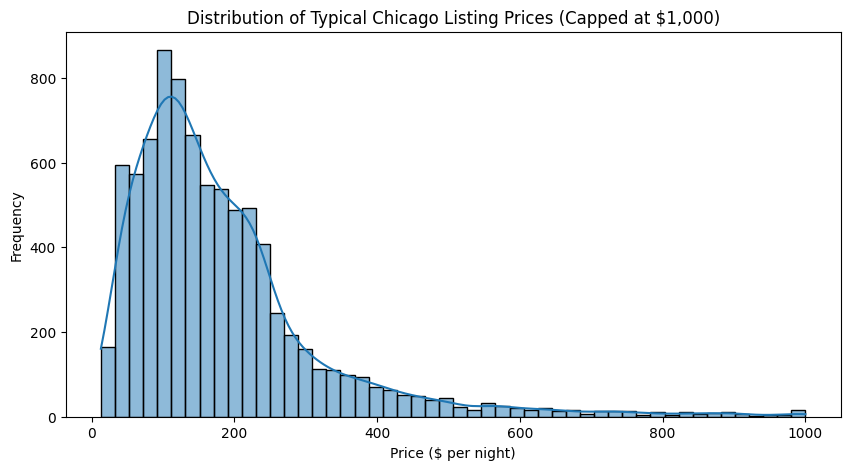

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to only look at properties below $1,000 a night
typical_prices = listing_df[listing_df['price'] <= 1000]

plt.figure(figsize=(10, 5))

# Adjust bins to make the distribution look smooth and continuous
sns.histplot(data=typical_prices, x='price', bins=50, kde=True)

plt.xlabel('Price ($ per night)')
plt.ylabel('Frequency')
plt.title('Distribution of Typical Chicago Listing Prices (Capped at $1,000)')

plt.show()

In [47]:
listing_df['price'] = listing_df['price'].fillna(listing_df.groupby(['neighbourhood', 'room_type'])['price'].transform('median'))

In [48]:
listing_df['price'].isna().sum()

np.int64(4)

In [49]:
listing_df.dropna(subset=['price'], inplace=True)

In [50]:
listing_df.isna().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0


In [51]:
def classify_rental_strategy(minimum_nights):
    if minimum_nights <= 2:
        return 'Short-Term'
    elif 3 <= minimum_nights <= 14:
        return 'Standard'
    elif 15 <= minimum_nights <= 31:
        return 'Medium-Term'
    else:
        return 'Long-Term'

listing_df['Rental_stratergy'] = listing_df['minimum_nights'].apply(classify_rental_strategy)

In [52]:
def classify_host(count):
    if count == 1:
        return 'Single'
    elif 2 <= count <= 5:
        return 'Small Business'
    else:
        return 'large scale business'

listing_df['host_business_type'] = listing_df['calculated_host_listings_count'].apply(classify_host)

In [53]:
listing_df['is_high_availability'] = (listing_df['availability_365'] > 220).astype(int)

In [54]:
listing_df.duplicated().sum()

np.int64(0)

In [55]:
listing_df['minimum_nights_capped'] = listing_df['minimum_nights'].clip(upper=35)

In [56]:
thresh_low = listing_df['number_of_reviews'].quantile(0.33)
thresh_high = listing_df['number_of_reviews'].quantile(0.66)

review_categories = []

for reviews in listing_df['number_of_reviews']:
    if reviews ==0:
        review_categories.append('No reviews')
    elif reviews <= thresh_low:
        review_categories.append('Low Reviewd')
    elif reviews <= thresh_high:
        review_categories.append('Moderate Reviewd')
    else:
        review_categories.append('High Reviewd')

listing_df['review_categories'] = review_categories
print(listing_df['review_categories'].value_counts())

review_categories
High Reviewd        2930
Moderate Reviewd    2729
No reviews          1685
Low Reviewd         1315
Name: count, dtype: int64


In [57]:
listing_df.to_csv('listings_cleaned.csv')